# 📊 Phase 1 — Exploratory Data Analysis (Raw Data)
> **Project:** Salary Range Prediction — NYC Job Postings  
> **Goal:** Understand the raw dataset, distributions, missing values, and key patterns before any cleaning.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")
os.makedirs("../eda_outputs/raw", exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

print("✓ Libraries loaded")

✓ Libraries loaded


## 2. Load Raw Data

In [14]:
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

print("Project Root:")
print(PROJECT_ROOT)

print("\nFiles inside data/raw:\n")

raw_dir = PROJECT_ROOT / "data" / "raw"

for file in raw_dir.iterdir():
    print(file.name)
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Jobs_NYC_Postings.csv"
CLEAN_DATA_PATH = DATA_DIR / "processed" / "salary_cleaned.csv"
# Load dataset
df = pd.read_csv(RAW_DATA_PATH)

print("Root Directory :", PROJECT_ROOT)
print("Raw Data Path  :", RAW_DATA_PATH)
print()

print(f"Shape     : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory    : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print("\nColumns:")
for col in df.columns:
    print(f"  • {col}")

Project Root:
D:\study_material\ProjectFinal\salary_range_prediction

Files inside data/raw:

Jobs_NYC_Postings.csv
Root Directory : D:\study_material\ProjectFinal\salary_range_prediction
Raw Data Path  : D:\study_material\ProjectFinal\salary_range_prediction\data\raw\Jobs_NYC_Postings.csv

Shape     : 5,120 rows × 30 columns
Memory    : 39.0 MB

Columns:
  • Job ID
  • Agency
  • Posting Type
  • # Of Positions
  • Business Title
  • Civil Service Title
  • Title Classification
  • Title Code No
  • Level
  • Job Category
  • Full-Time/Part-Time indicator
  • Career Level
  • Salary Range From
  • Salary Range To
  • Salary Frequency
  • Work Location
  • Division/Work Unit
  • Job Description
  • Minimum Qual Requirements
  • Preferred Skills
  • Additional Information
  • To Apply
  • Hours/Shift
  • Work Location 1
  • Recruitment Contact
  • Residency Requirement
  • Posting Date
  • Post Until
  • Posting Updated
  • Process Date


In [15]:
# Preview first 5 rows
df.head()

,Job ID,Agency,Posting Type,# Of Positions,Business Title,Civil Service Title,Title Classification,Title Code No,Level,Job Category,...,Additional Information,To Apply,Hours/Shift,Work Location 1,Recruitment Contact,Residency Requirement,Posting Date,Post Until,Posting Updated,Process Date
0,623668,DEPT OF HEALTH/MENTAL HYGIENE,External,1,"Research Analyst, IMAT, Bureau of Maternal Inf...",CITY RESEARCH SCIENTIST,Non-Competitive-5,21744,2,Constituent Services & Community Programs Heal...,...,**IMPORTANT NOTES TO ALL CANDIDATES: Please n...,Apply online with a cover letter to https://a1...,NaN,NaN,NaN,New York City residency is generally required ...,01/23/2024,22-May-2024,01/23/2024,03/04/2024
1,608193,DEPT OF DESIGN & CONSTRUCTION,Internal,1,Deputy Director,ADMINISTRATIVE PROJECT MANAGER,Competitive-1,8300B,0,"Policy, Research & Analysis Public Safety, Ins...",...,Authorization to work in the United States is ...,"For City Employees, please go to Employee Self...",35 Hours,"30-30 Thomson Avenue, LIC, NY 11101",NaN,New York City Residency is not required for th...,10/03/2023,NaN,11/29/2023,03/04/2024
2,625094,DEPT OF DESIGN & CONSTRUCTION,Internal,1,Senior Project Manager,ADMINISTRATIVE PROJECT MANAGER,Competitive-1,8300B,0,"Engineering, Architecture, & Planning",...,NaN,NaN,NaN,NaN,NaN,New York City Residency is not required for th...,02/01/2024,NaN,02/01/2024,03/04/2024
3,580593,DEPARTMENT OF TRANSPORTATION,External,1,Procurement Analyst 2,PROCUREMENT ANALYST,Competitive-1,12158,2,"Finance, Accounting, & Procurement",...,The City of New York is an inclusive equal opp...,Resumes may be submitted electronically using ...,9:00am â 5:00pm,To be determine.,NaN,New York City residency is generally required ...,04/04/2023,NaN,04/04/2023,03/04/2024
4,624937,DEPT OF HEALTH/MENTAL HYGIENE,External,1,"Deputy Director, HIV Planning Council, Divisio...",CITY RESEARCH SCIENTIST,Non-Competitive-5,21744,3,Constituent Services & Community Programs Heal...,...,NaN,Apply online with a cover letter to https://a1...,NaN,NaN,NaN,New York City residency is generally required ...,02/06/2024,05-Jun-2024,02/21/2024,03/04/2024


In [16]:
# Data types
df.dtypes

Job ID                             int64
Agency                            object
Posting Type                      object
# Of Positions                     int64
Business Title                    object
Civil Service Title               object
Title Classification              object
Title Code No                     object
Level                             object
Job Category                      object
Full-Time/Part-Time indicator     object
Career Level                      object
Salary Range From                float64
Salary Range To                  float64
Salary Frequency                  object
Work Location                     object
Division/Work Unit                object
Job Description                   object
Minimum Qual Requirements         object
Preferred Skills                  object
Additional Information            object
To Apply                          object
Hours/Shift                       object
Work Location 1                   object
Recruitment Cont

In [17]:
# Numeric summary statistics
df.describe().round(2)

,Job ID,# Of Positions,Salary Range From,Salary Range To,Recruitment Contact
count,5120.00,5120.00,5120.00,5120.00,0.0
mean,598721.37,2.07,64625.22,89978.58,NaN
std,28274.64,5.80,31378.52,46732.30,NaN
min,469953.00,1.00,0.00,15.00,NaN
25%,586358.00,1.00,51869.00,64608.00,NaN
50%,607060.00,1.00,62397.00,85147.00,NaN
75%,621404.00,1.00,80557.00,113550.00,NaN
max,628806.00,150.00,225000.00,252165.00,NaN


## 3. Missing Values Analysis

In [18]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).sort_values("Missing Count", ascending=False)
missing_df = missing_df[missing_df["Missing Count"] > 0]

print(missing_df.to_string())

                               Missing Count  Missing %
Recruitment Contact                     5120      100.0
Post Until                              3616       70.6
Work Location 1                         3229       63.1
Hours/Shift                             3210       62.7
Additional Information                  1862       36.4
Preferred Skills                        1219       23.8
To Apply                                 426        8.3
Full-Time/Part-Time indicator            117        2.3
Minimum Qual Requirements                 43        0.8


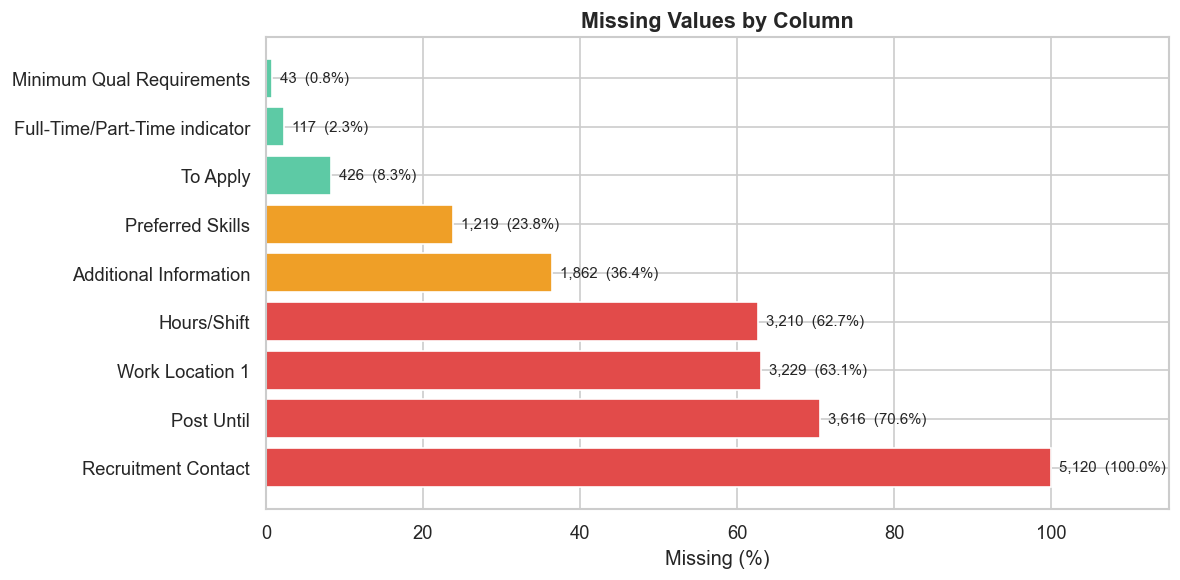

✓ Saved: eda_outputs/raw/01_missing_values.png


In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#E24B4A" if p > 50 else "#EF9F27" if p > 10 else "#5DCAA5"
          for p in missing_df["Missing %"]]
bars = ax.barh(missing_df.index, missing_df["Missing %"], color=colors)
ax.set_xlabel("Missing (%)")
ax.set_title("Missing Values by Column", fontsize=13, fontweight="bold")
ax.set_xlim(0, 115)
for bar, (count, pct) in zip(bars, zip(missing_df["Missing Count"], missing_df["Missing %"])):
    ax.text(pct + 1, bar.get_y() + bar.get_height() / 2,
            f"{count:,}  ({pct}%)", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../eda_outputs/raw/01_missing_values.png")
plt.show()
print("✓ Saved: eda_outputs/raw/01_missing_values.png")

## 4. Salary Frequency Breakdown

In [20]:
freq_counts = df["Salary Frequency"].value_counts()
print(freq_counts)

Salary Frequency
Annual    4686
Hourly     384
Daily       50
Name: count, dtype: int64


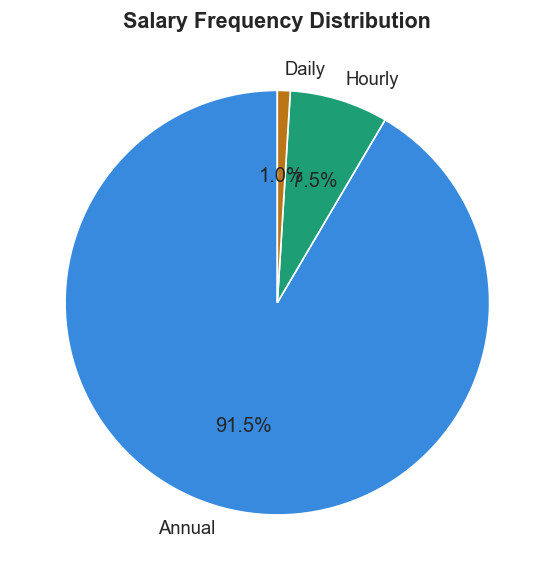

✓ Saved: eda_outputs/raw/02_salary_frequency_pie.png


In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(freq_counts, labels=freq_counts.index, autopct="%1.1f%%",
       colors=["#378ADD", "#1D9E75", "#BA7517"], startangle=90)
ax.set_title("Salary Frequency Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../eda_outputs/raw/02_salary_frequency_pie.png")
plt.show()
print("✓ Saved: eda_outputs/raw/02_salary_frequency_pie.png")

In [22]:
# Stats per frequency type
for freq in ["Annual", "Hourly", "Daily"]:
    sub = df[df["Salary Frequency"] == freq]
    print(f"{freq} (n={len(sub):,}):")
    print(f"  Salary From → min: {sub['Salary Range From'].min():.2f},  "
          f"max: {sub['Salary Range From'].max():.2f},  "
          f"mean: {sub['Salary Range From'].mean():.2f}")
    print(f"  Salary To   → min: {sub['Salary Range To'].min():.2f},  "
          f"max: {sub['Salary Range To'].max():.2f},  "
          f"mean: {sub['Salary Range To'].mean():.2f}")
    print()

Annual (n=4,686):
  Salary From → min: 0.00,  max: 225000.00,  mean: 70604.53
  Salary To   → min: 35252.00,  max: 252165.00,  mean: 98305.49

Hourly (n=384):
  Salary From → min: 15.00,  max: 79.23,  mean: 31.60
  Salary To   → min: 15.00,  max: 98.84,  mean: 35.39

Daily (n=50):
  Salary From → min: 82.23,  max: 618.24,  mean: 323.26
  Salary To   → min: 82.23,  max: 618.24,  mean: 344.17



## 5. Annual Salary Distribution

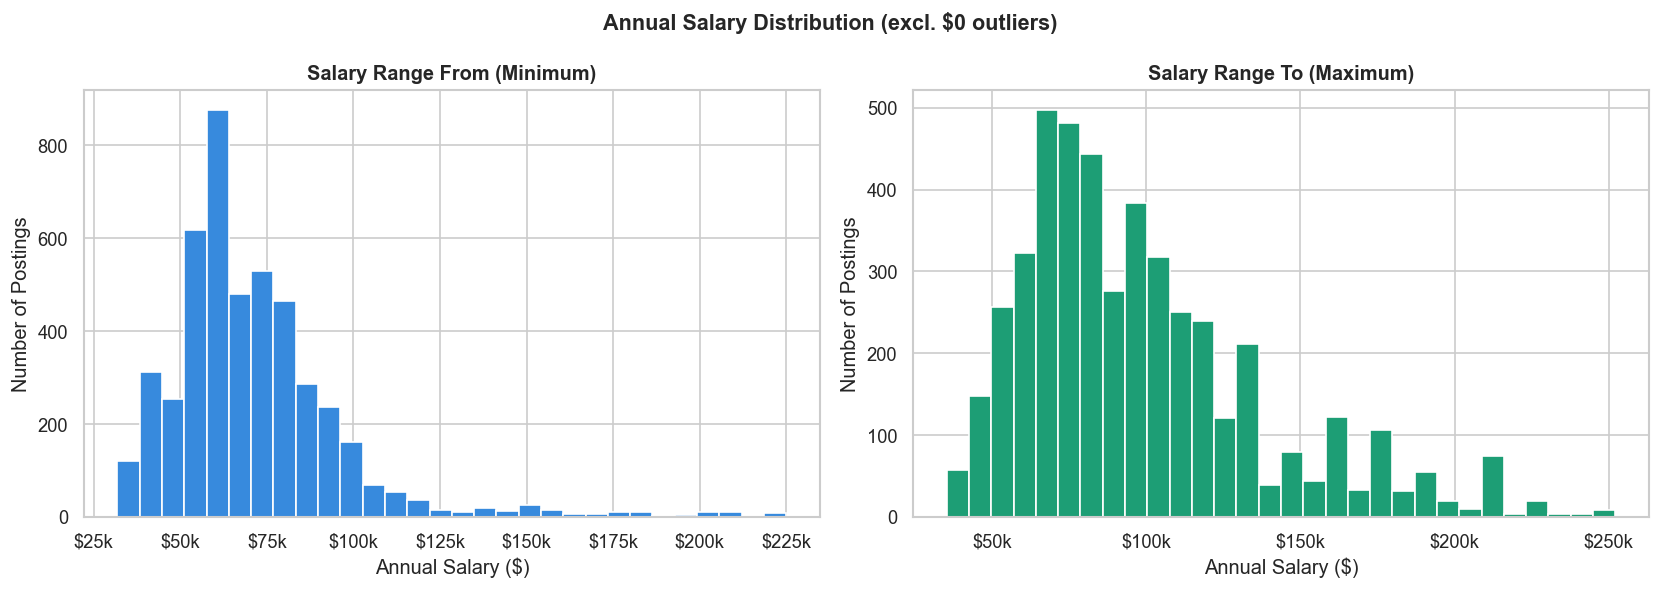

✓ Saved: eda_outputs/raw/03_salary_distribution_histograms.png


In [23]:
ann = df[df["Salary Frequency"] == "Annual"].copy()
ann_clean = ann[ann["Salary Range From"] > 1000]   # exclude $0 outliers for visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ann_clean["Salary Range From"], bins=30, color="#378ADD", edgecolor="white")
axes[0].set_title("Salary Range From (Minimum)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Annual Salary ($)")
axes[0].set_ylabel("Number of Postings")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

axes[1].hist(ann_clean["Salary Range To"], bins=30, color="#1D9E75", edgecolor="white")
axes[1].set_title("Salary Range To (Maximum)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Annual Salary ($)")
axes[1].set_ylabel("Number of Postings")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

plt.suptitle("Annual Salary Distribution (excl. $0 outliers)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../eda_outputs/raw/03_salary_distribution_histograms.png")
plt.show()
print("✓ Saved: eda_outputs/raw/03_salary_distribution_histograms.png")

## 6. Salary by Career Level

In [24]:
career_stats = ann.groupby("Career Level")[["Salary Range From","Salary Range To"]].median().round(0)
print(career_stats.sort_values("Salary Range From"))

                           Salary Range From  Salary Range To
Career Level                                                 
Entry-Level                          50972.0          60000.0
Student                              54272.0          83117.0
Experienced (non-manager)            64922.0          86830.0
Manager                              80931.0         144066.0
Executive                           130000.0         190000.0


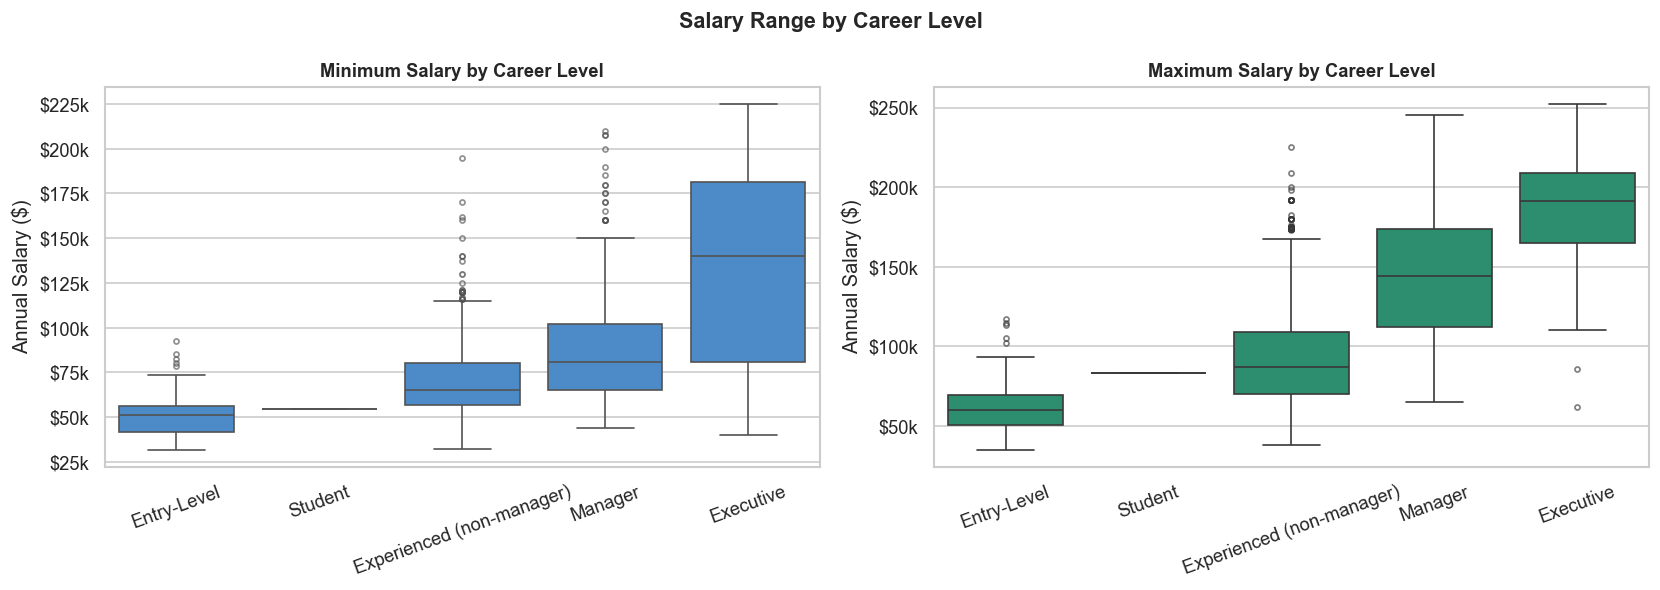

✓ Saved: eda_outputs/raw/04_salary_by_career_level.png


In [25]:
order = ["Entry-Level", "Student", "Experienced (non-manager)", "Manager", "Executive"]
order = [o for o in order if o in ann["Career Level"].unique()]
plot_data = ann[ann["Salary Range From"] > 1000]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color in zip(axes,
                           ["Salary Range From", "Salary Range To"],
                           ["#378ADD", "#1D9E75"]):
    sns.boxplot(data=plot_data, x="Career Level", y=col, order=order,
                color=color, ax=ax, flierprops=dict(marker="o", markersize=3, alpha=0.4))
    ax.set_xlabel("")
    ax.set_ylabel("Annual Salary ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
    ax.tick_params(axis="x", rotation=20)

axes[0].set_title("Minimum Salary by Career Level", fontsize=11, fontweight="bold")
axes[1].set_title("Maximum Salary by Career Level", fontsize=11, fontweight="bold")
plt.suptitle("Salary Range by Career Level", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../eda_outputs/raw/04_salary_by_career_level.png")
plt.show()
print("✓ Saved: eda_outputs/raw/04_salary_by_career_level.png")

## 7. Salary by Job Category

In [26]:
top_cats = ann["Job Category"].value_counts().head(10).index
cat_stats = (ann[ann["Job Category"].isin(top_cats)]
             .groupby("Job Category")[["Salary Range From","Salary Range To"]]
             .median().round(0)
             .sort_values("Salary Range From", ascending=True))
print(cat_stats.to_string())

                                                                              Salary Range From  Salary Range To
Job Category                                                                                                    
Social Services                                                                         56677.0          69709.0
Health                                                                                  58695.0          72033.0
Administration & Human Resources Social Services                                        59116.0          77050.0
Administration & Human Resources                                                        60718.0          78501.0
Public Safety, Inspections, & Enforcement                                               61689.0          79000.0
Constituent Services & Community Programs Health Policy, Research & Analysis            63962.0          81346.0
Engineering, Architecture, & Planning                                                   65208.0 

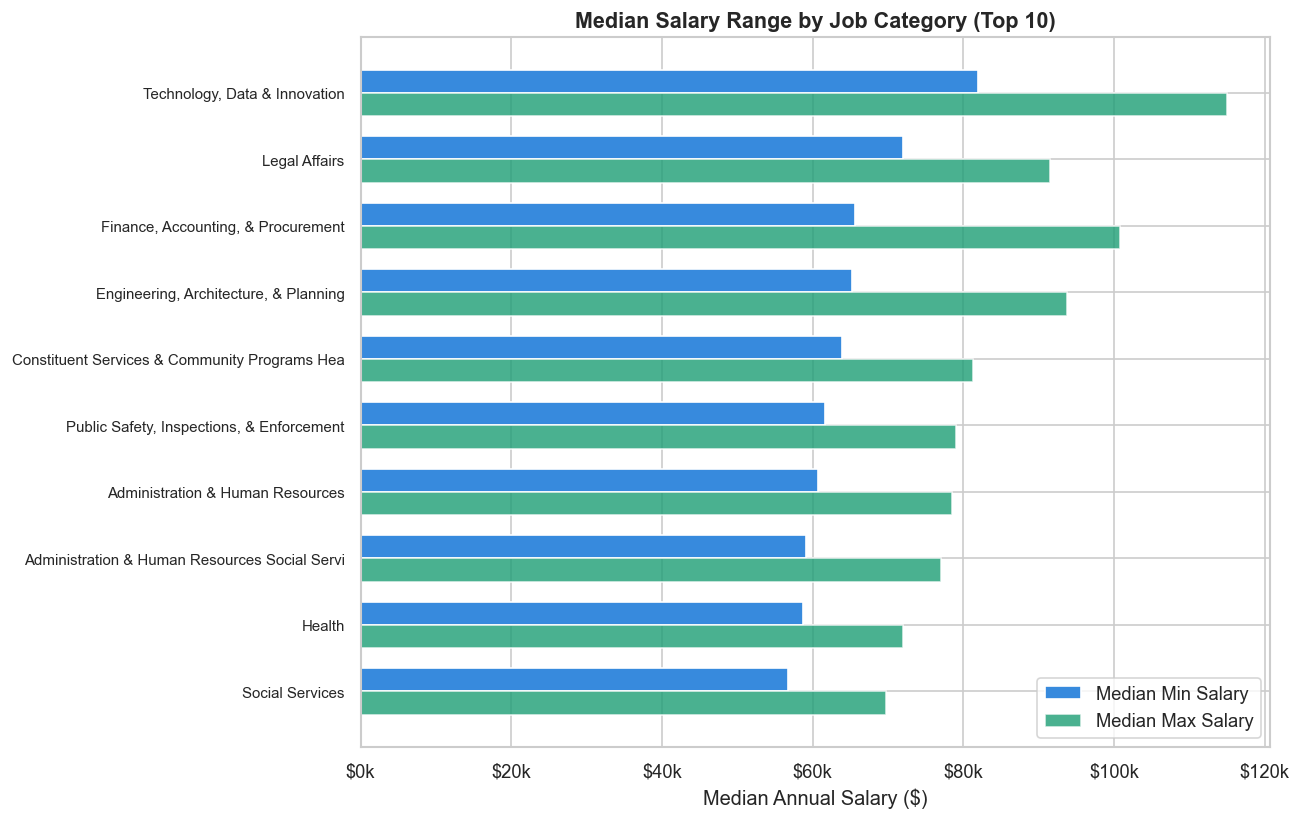

✓ Saved: eda_outputs/raw/05_salary_by_job_category.png


In [27]:
fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(cat_stats))
h = 0.35
ax.barh(y + h/2, cat_stats["Salary Range From"], height=h, color="#378ADD", label="Median Min Salary")
ax.barh(y - h/2, cat_stats["Salary Range To"],   height=h, color="#1D9E75", label="Median Max Salary", alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels([c[:45] for c in cat_stats.index], fontsize=9)
ax.set_xlabel("Median Annual Salary ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_title("Median Salary Range by Job Category (Top 10)", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../eda_outputs/raw/05_salary_by_job_category.png")
plt.show()
print("✓ Saved: eda_outputs/raw/05_salary_by_job_category.png")

## 8. Outlier Analysis

In [28]:
print("Annual salary outliers:")
print(f"  Salary From == $0        : {(ann['Salary Range From'] == 0).sum()}")
print(f"  Salary From  < $10,000   : {(ann['Salary Range From'] < 10000).sum()}")
print(f"  Salary From  > $200,000  : {(ann['Salary Range From'] > 200000).sum()}")
print(f"  Min == Max (fixed salary): {(ann['Salary Range From'] == ann['Salary Range To']).sum()}")
print(f"  Min  > Max (bad record)  : {(ann['Salary Range From'] >  ann['Salary Range To']).sum()}")

print("\nPercentiles (Annual Salary From):")
for p in [1, 5, 25, 50, 75, 95, 99]:
    val = ann["Salary Range From"].quantile(p / 100)
    print(f"  P{p:>2}: ${val:,.0f}")

Annual salary outliers:
  Salary From == $0        : 23
  Salary From  < $10,000   : 23
  Salary From  > $200,000  : 20
  Min == Max (fixed salary): 464
  Min  > Max (bad record)  : 0

Percentiles (Annual Salary From):
  P 1: $33,558
  P 5: $40,017
  P25: $56,625
  P50: $65,000
  P75: $81,571
  P95: $110,000
  P99: $175,000


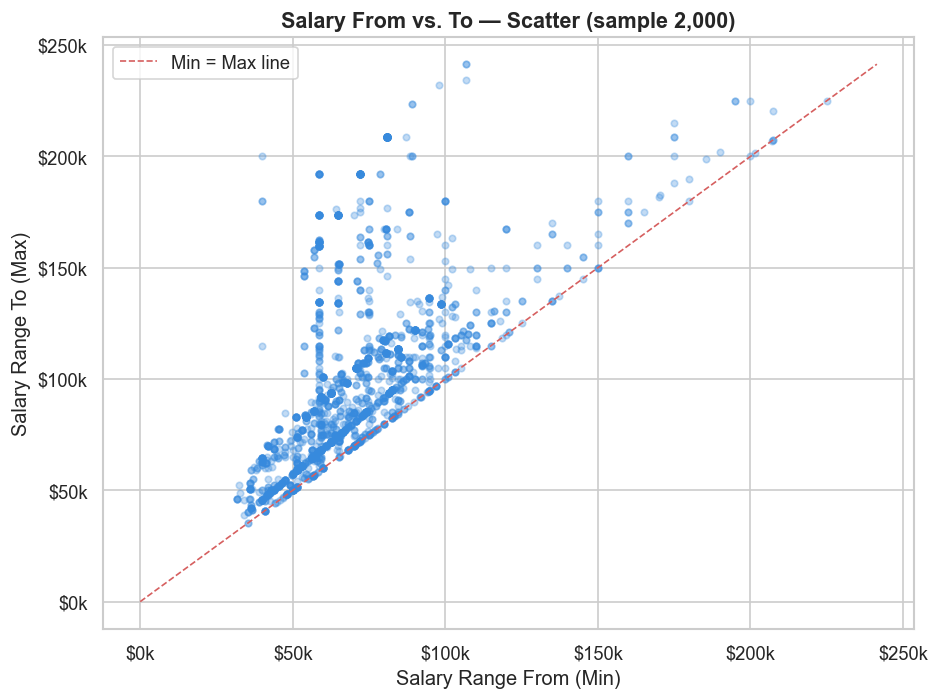

✓ Saved: eda_outputs/raw/06_salary_scatter.png


In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
sample = ann[ann["Salary Range From"] > 1000].sample(min(2000, len(ann)), random_state=42)
ax.scatter(sample["Salary Range From"], sample["Salary Range To"],
           alpha=0.3, s=15, color="#378ADD")
max_val = max(sample["Salary Range From"].max(), sample["Salary Range To"].max())
ax.plot([0, max_val], [0, max_val], "r--", linewidth=1, label="Min = Max line")
ax.set_xlabel("Salary Range From (Min)")
ax.set_ylabel("Salary Range To (Max)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_title("Salary From vs. To — Scatter (sample 2,000)", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../eda_outputs/raw/06_salary_scatter.png")
plt.show()
print("✓ Saved: eda_outputs/raw/06_salary_scatter.png")

## 9. Correlation Heatmap (Numeric Columns)

In [32]:
num_cols = ["# Of Positions", "Salary Range From", "Salary Range To"]
corr = df[num_cols].corr().round(2)
print(corr)

                   # Of Positions  Salary Range From  Salary Range To
# Of Positions               1.00              -0.09            -0.10
Salary Range From           -0.09               1.00             0.76
Salary Range To             -0.10               0.76             1.00


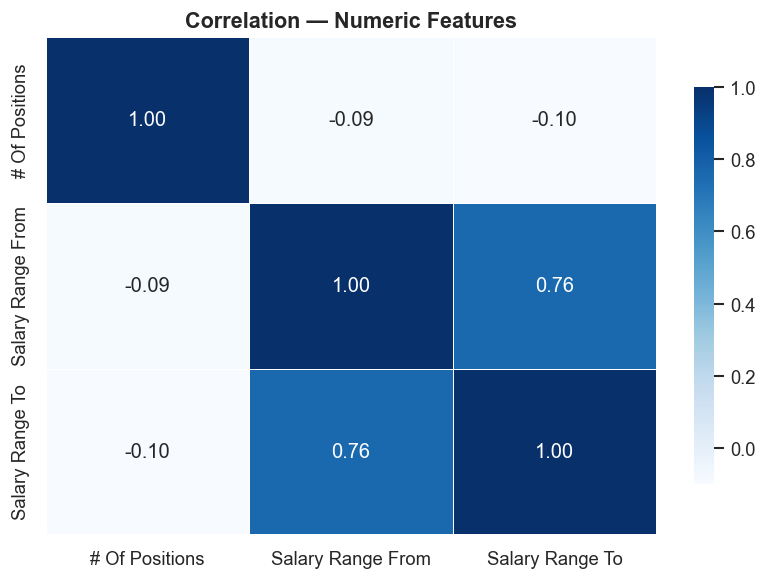

✓ Saved: eda_outputs/raw/07_correlation_heatmap.png


In [33]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues",
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation — Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../eda_outputs/raw/07_correlation_heatmap.png")
plt.show()
print("✓ Saved: eda_outputs/raw/07_correlation_heatmap.png")

## 10. Job Category & Agency Distribution

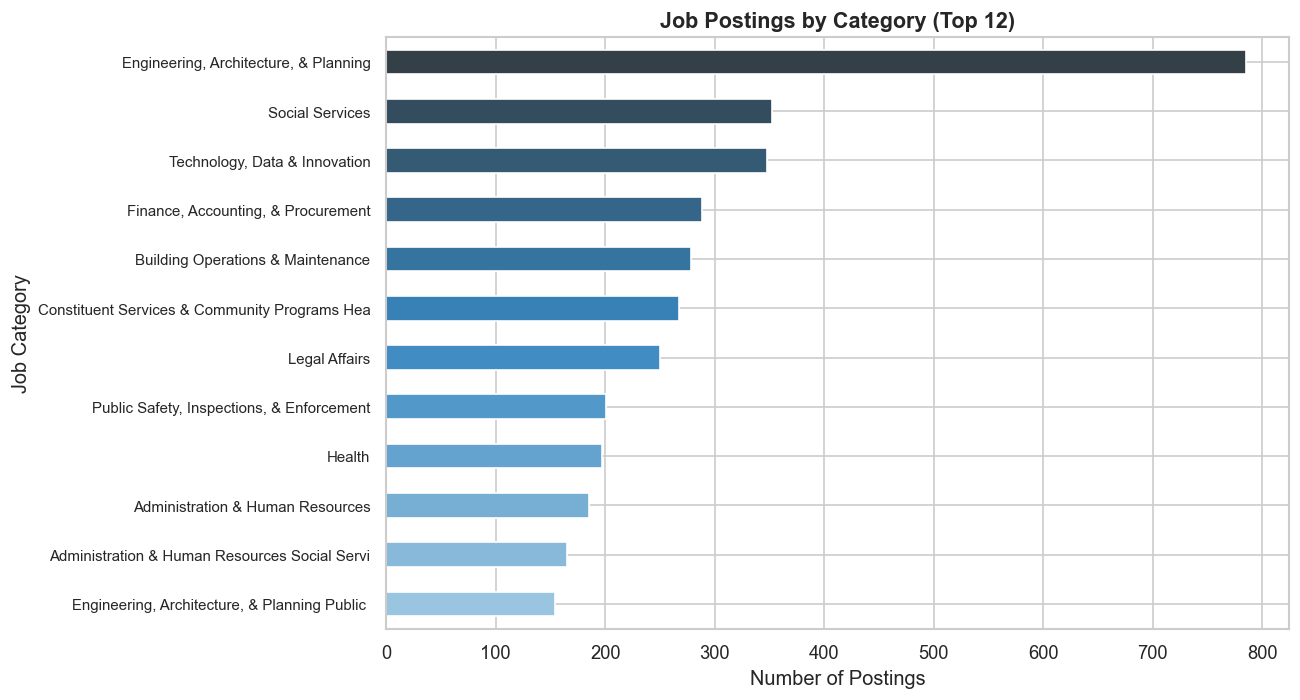

✓ Saved: eda_outputs/raw/08_job_category_counts.png


In [34]:
top_cat_counts = df["Job Category"].value_counts().head(12)

fig, ax = plt.subplots(figsize=(11, 6))
colors = sns.color_palette("Blues_d", len(top_cat_counts))
top_cat_counts.sort_values().plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Number of Postings")
ax.set_title("Job Postings by Category (Top 12)", fontsize=13, fontweight="bold")
ax.set_yticklabels([c[:45] for c in top_cat_counts.sort_values().index], fontsize=9)
plt.tight_layout()
plt.savefig("../eda_outputs/raw/08_job_category_counts.png")
plt.show()
print("✓ Saved: eda_outputs/raw/08_job_category_counts.png")

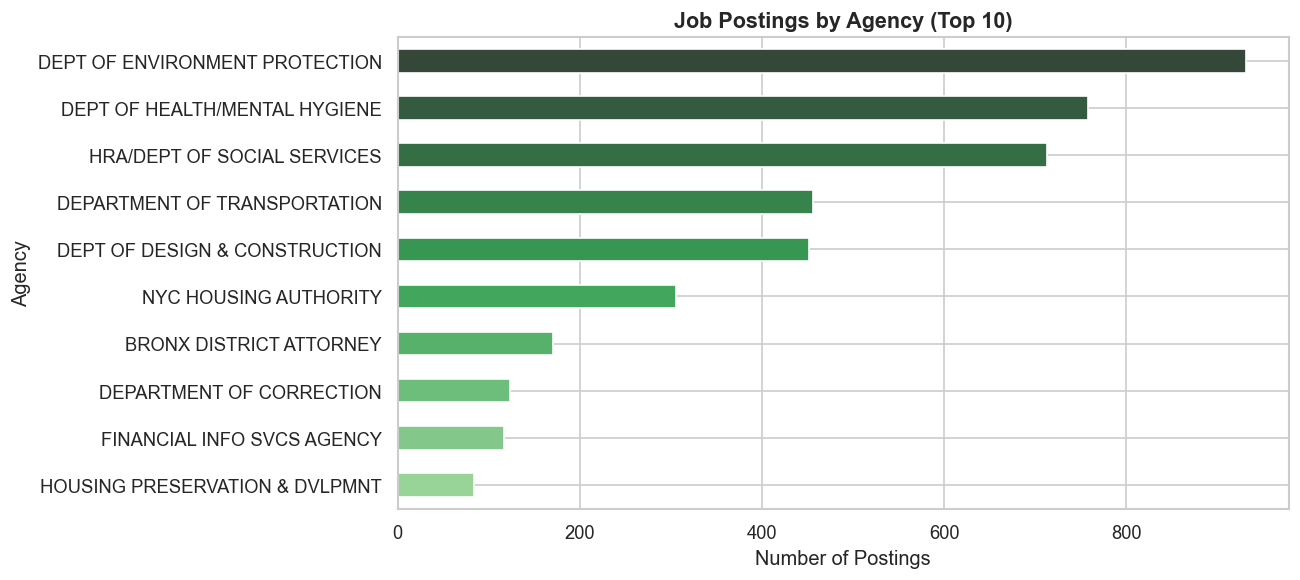

✓ Saved: eda_outputs/raw/09_agency_counts.png


In [35]:
top_agency_counts = df["Agency"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
colors = sns.color_palette("Greens_d", len(top_agency_counts))
top_agency_counts.sort_values().plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Number of Postings")
ax.set_title("Job Postings by Agency (Top 10)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../eda_outputs/raw/09_agency_counts.png")
plt.show()
print("✓ Saved: eda_outputs/raw/09_agency_counts.png")

## ✅ Phase 1 EDA Complete
**Key Findings:**
- 5,120 job postings, 30 columns
- 91.5% Annual, 7.5% Hourly, 1% Daily salary frequencies → need normalization
- 23 records with $0 salary → remove before modeling
- Recruitment Contact is 100% missing → drop
- Clear salary ladder: Entry-Level ($50k) → Executive ($130k)
- Technology & Innovation is the highest-paying category